In [5]:
import pandas as pd

NUM_MIN = 4
NUM_MAX = 16

df = pd.read_csv('centroides2.csv')
df.head()

,Unnamed: 0,cluster,lat,lon,num_points,adjustment_status
0,0,0.0,41.881373,12.510368,481.0,Moved out of Zone
1,1,1.0,41.901050,12.465224,351.0,Moved out of Zone
2,2,2.0,41.856676,12.477809,287.0,Moved out of Zone
3,3,3.0,41.913563,12.520829,242.0,Moved out of Zone
4,4,4.0,41.876901,12.465899,235.0,Moved out of Zone


In [10]:
cluster_sizes = df['num_points']
print("Extracted cluster sizes:")
print(cluster_sizes.head())

Extracted cluster sizes:
0    481.0
1    351.0
2    287.0
3    242.0
4    235.0
Name: num_points, dtype: float64


In [11]:
bin_width = 20
min_val = int(cluster_sizes.min() // bin_width * bin_width)
max_val = int((cluster_sizes.max() // bin_width + 1) * bin_width)
bins = list(range(min_val, max_val + bin_width, bin_width))

bin_labels = [f"{i}-{i+bin_width-1}" for i in bins[:-1]]

binned_data = pd.cut(cluster_sizes, bins=bins, labels=bin_labels, right=False)

bin_counts = binned_data.value_counts().sort_index()

print("Cluster counts per bin:")
print(bin_counts)


Cluster counts per bin:
num_points
40-59       2
60-79       4
80-99       7
100-119    10
120-139    17
140-159     9
160-179    10
180-199    14
200-219    12
220-239    12
240-259    15
260-279    10
280-299    11
300-319     8
320-339    10
340-359     6
360-379     7
380-399     4
400-419     4
420-439     4
440-459     1
460-479     0
480-499     5
500-519     1
520-539     1
540-559     1
560-579     0
580-599     0
600-619     0
620-639     2
640-659     0
660-679     0
680-699     0
700-719     1
720-739     0
740-759     0
760-779     0
780-799     0
800-819     1
820-839     0
840-859     0
860-879     0
880-899     1
Name: count, dtype: int64


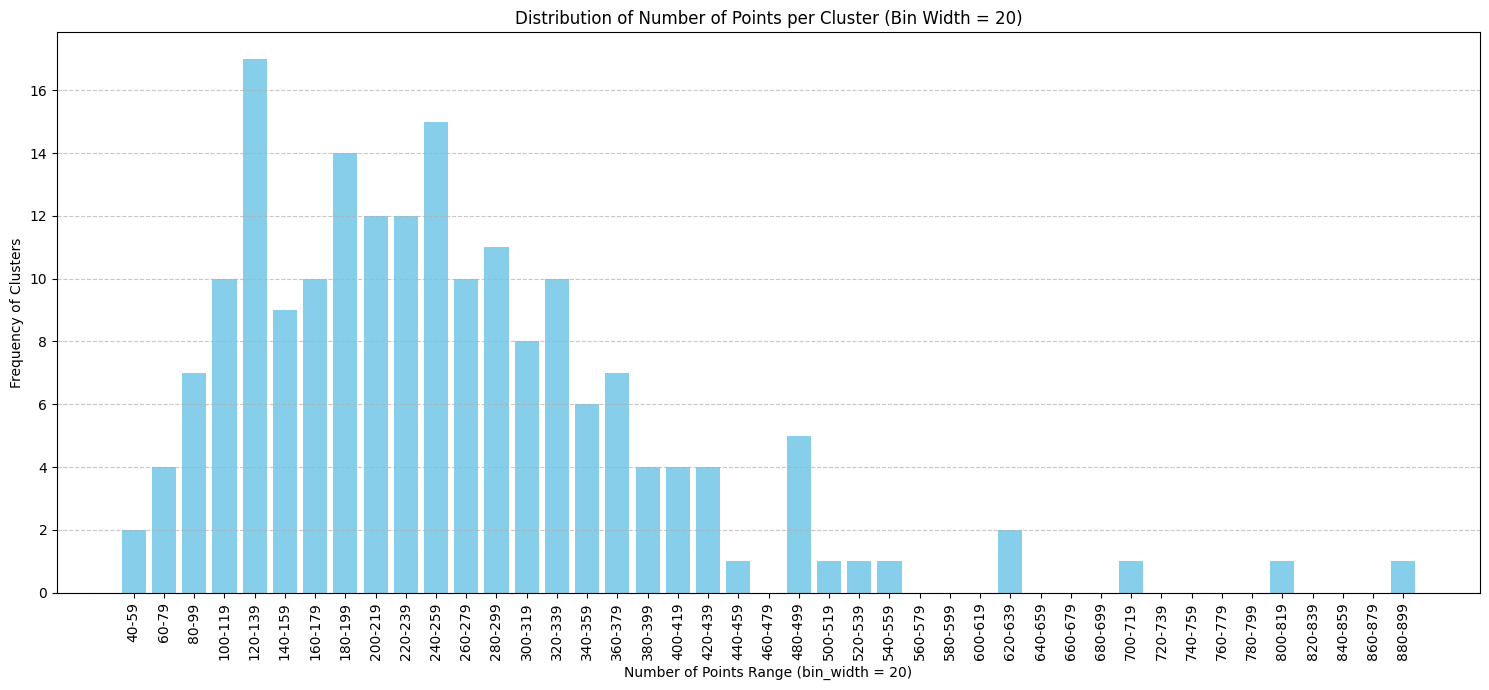

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.bar(bin_counts.index, bin_counts.values, color='skyblue')
plt.xlabel('Number of Points Range (bin_width = 20)')
plt.ylabel('Frequency of Clusters')
plt.title('Distribution of Number of Points per Cluster (Bin Width = 20)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

A partir de aquí, vamos a calcular cual es el número máximo de patinetes que coinciden en cada estación.

Primero, hacemos el ejemplo de un día.

In [16]:
viajes_df = pd.read_csv('potenciales_viajes_cubiertos.csv')[['idS', 'tsO', 'tsD', 'clusterOrigen', 'clusterFinal']]
viajes_df['tsO'] = pd.to_datetime(viajes_df['tsO'])
viajes_df['tsD'] = pd.to_datetime(viajes_df['tsD'])
viajes_df.head()

,idS,tsO,tsD,clusterOrigen,clusterFinal
0,A0H4,2021-02-03 18:10:03,2021-02-03 18:17:44,174.0,122.0
1,A0H4,2021-02-13 18:21:13,2021-02-13 18:25:33,59.0,98.0
2,A0H4,2021-02-14 13:39:54,2021-02-14 13:48:03,98.0,137.0
3,A0H4,2021-02-14 14:37:53,2021-02-14 14:57:53,137.0,113.0
4,A0H4,2021-02-15 13:31:24,2021-02-15 13:34:45,113.0,179.0


In [18]:
viajes_03_02_df = viajes_df[(viajes_df['tsO'] >= '2021-02-03 00:00:00') & (viajes_df['tsD'] <= '2021-02-04 00:00:00')]
viajes_03_02_df

,idS,tsO,tsD,clusterOrigen,clusterFinal
0,A0H4,2021-02-03 18:10:03,2021-02-03 18:17:44,174.0,122.0
16,A0K5,2021-02-03 17:45:03,2021-02-03 18:01:03,35.0,177.0
48,A0N7,2021-02-03 16:57:54,2021-02-03 17:01:14,116.0,46.0
49,A0N7,2021-02-03 18:56:14,2021-02-03 18:59:33,46.0,116.0
105,A0U7,2021-02-03 16:51:43,2021-02-03 17:15:04,101.0,107.0
...,...,...,...,...,...
20130,Z7P5,2021-02-03 12:55:03,2021-02-03 12:59:13,101.0,17.0
20131,Z7P5,2021-02-03 22:10:53,2021-02-03 22:13:13,17.0,173.0
20146,Z7Z1,2021-02-03 15:31:33,2021-02-03 15:53:03,140.0,174.0
20150,Z7Z7,2021-02-03 17:59:23,2021-02-03 18:28:14,79.0,179.0


/tmp/ipython-input-1988031757.py:59: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  station_state_resampled = station_state.resample('1T').ffill()
/tmp/ipython-input-1988031757.py:75: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


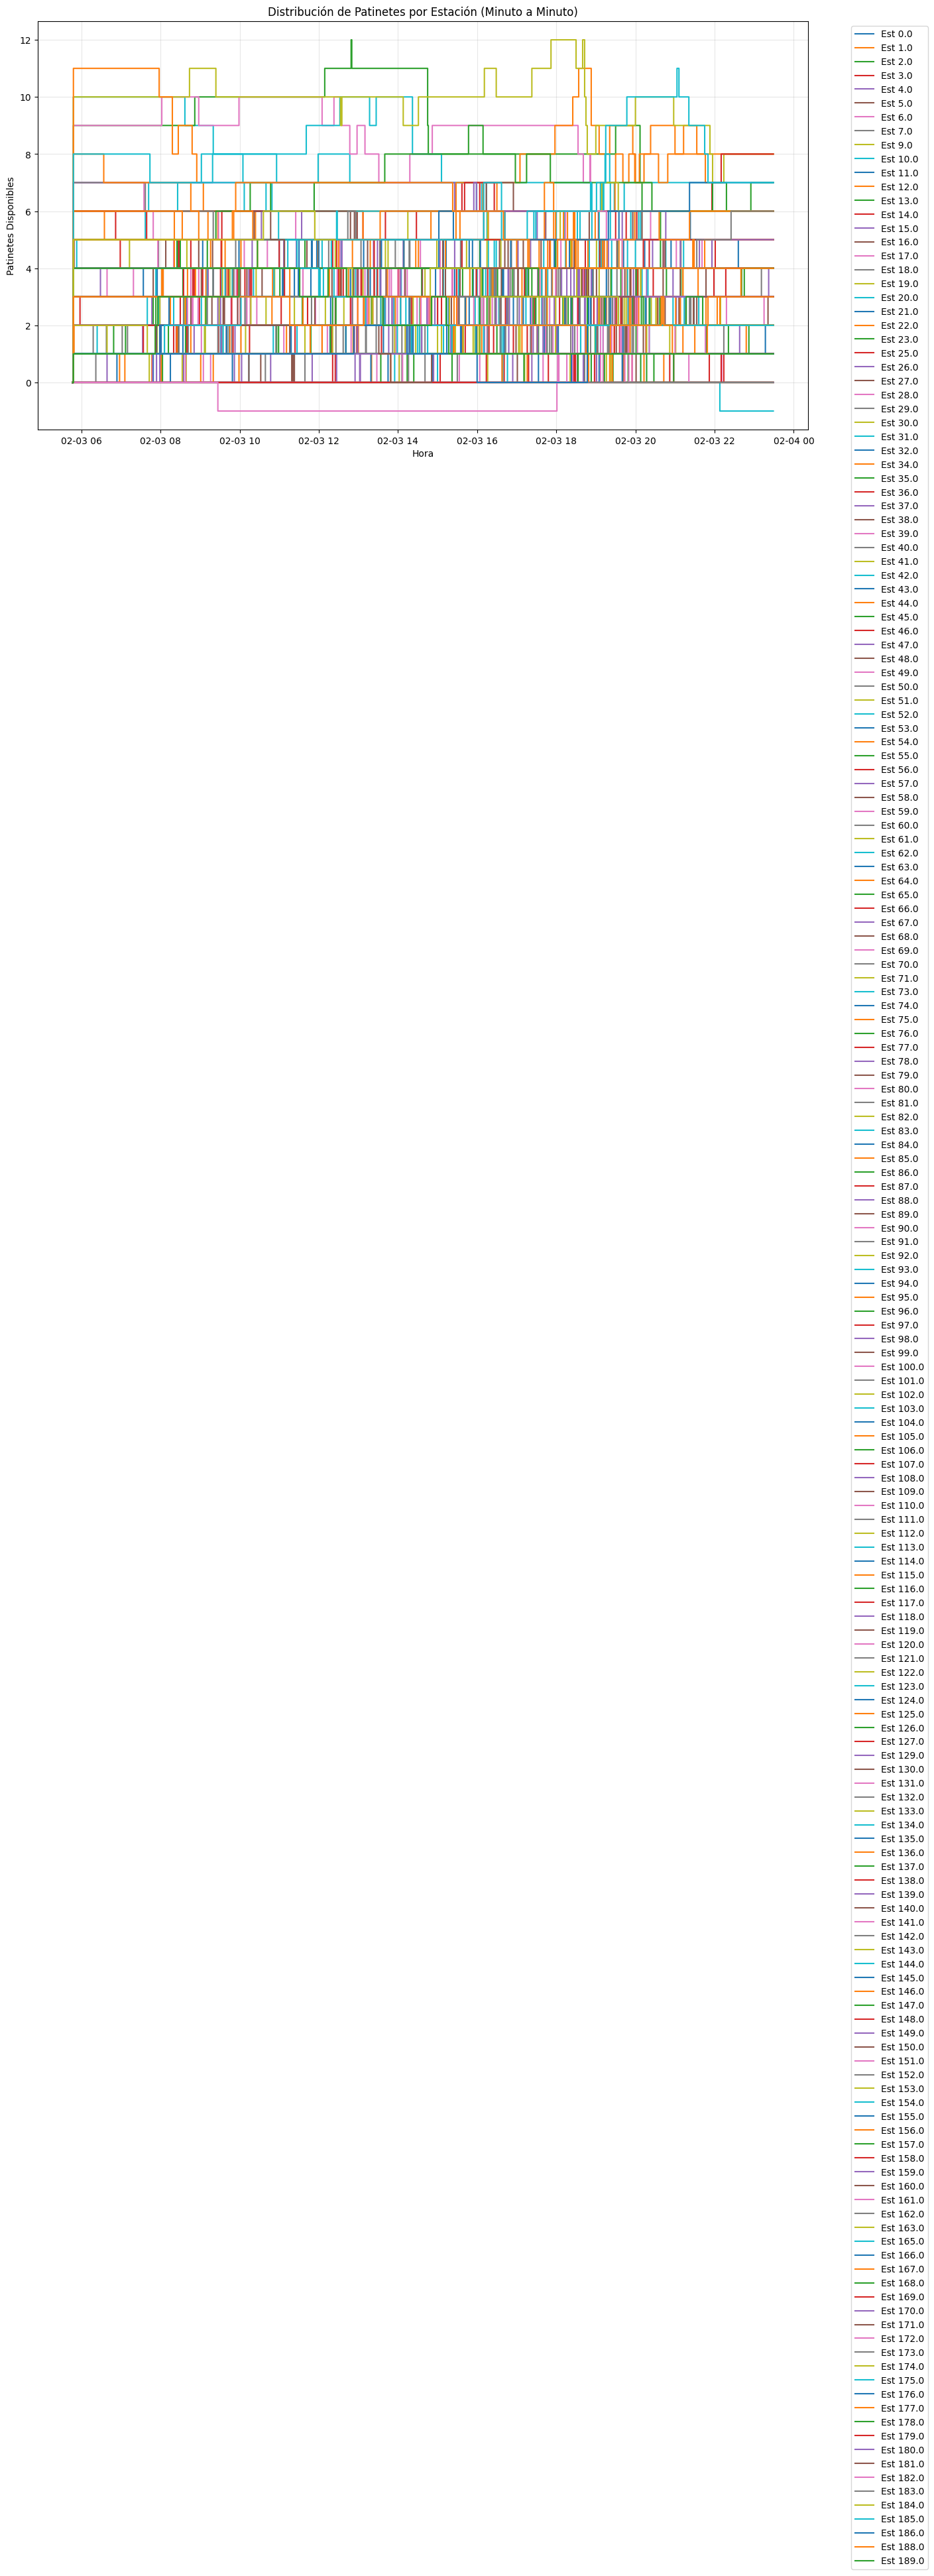

Station              0.0    1.0    2.0    3.0    4.0    5.0    6.0    7.0    \
Time                                                                          
2021-02-03 05:47:00    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
2021-02-03 05:48:00    1.0    0.0    2.0    6.0    0.0    3.0    2.0    2.0   
2021-02-03 05:49:00    1.0    0.0    2.0    6.0    0.0    3.0    2.0    2.0   
2021-02-03 05:50:00    1.0    0.0    2.0    6.0    0.0    3.0    2.0    2.0   
2021-02-03 05:51:00    1.0    0.0    2.0    6.0    0.0    3.0    2.0    2.0   

Station              9.0    10.0   ...  179.0  180.0  181.0  182.0  183.0  \
Time                               ...                                      
2021-02-03 05:47:00    0.0    0.0  ...    0.0    0.0    0.0    0.0    0.0   
2021-02-03 05:48:00    3.0    5.0  ...    0.0    0.0    3.0    0.0    3.0   
2021-02-03 05:49:00    3.0    5.0  ...    0.0    0.0    3.0    0.0    3.0   
2021-02-03 05:50:00    3.0    5.0  ...    0.0    0.0    3.0  

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. PREPARACIÓN DE DATOS
# Hacemos una copia para no modificar el original
df = viajes_03_02_df.copy()

# Asegúrate de que las columnas de tiempo sean datetime
df['StartTime'] = pd.to_datetime(df['tsO'])
df['EndTime'] = pd.to_datetime(df['tsD'])

# 2. DEFINIR EL ESTADO INICIAL
# Asumimos que antes del primer viaje, el patinete estaba en la estación de Origen
first_trips = df.sort_values('StartTime').groupby('idS').first().reset_index()
start_time_global = df['StartTime'].min() - pd.Timedelta(minutes=1)

initial_events = []
for _, row in first_trips.iterrows():
    initial_events.append({
        'Time': start_time_global,
        'Station': row['clusterOrigen'],
        'Change': 1  # +1 patinete en el origen inicial
    })

# 3. CREAR LA LISTA DE EVENTOS (SALIDAS Y LLEGADAS)
trip_events = []
for _, row in df.iterrows():
    # Evento de Salida (Patinete deja la estación de origen)
    trip_events.append({
        'Time': row['StartTime'],
        'Station': row['clusterOrigen'],
        'Change': -1
    })
    # Evento de Llegada (Patinete llega a la estación de destino)
    trip_events.append({
        'Time': row['EndTime'],
        'Station': row['clusterFinal'],
        'Change': 1
    })

# 4. PROCESAR Y AGREGAR
# Juntamos todos los eventos
all_events = initial_events + trip_events
events_df = pd.DataFrame(all_events)

# Ordenamos cronológicamente
events_df = events_df.sort_values('Time')

# Creamos una tabla dinámica: Filas = Tiempo, Columnas = Estaciones
# Sumamos los cambios (Change) por si ocurren varios en el mismo minuto
pivot_events = events_df.groupby(['Time', 'Station'])['Change'].sum().unstack(fill_value=0)

# Calculamos el acumulado (stock de patinetes) en el tiempo
station_state = pivot_events.cumsum()

# 5. RESAMPLEO (RELLENAR HUECOS TEMPORALES)
# Esto crea una fila por cada minuto, manteniendo el valor anterior (ffill)
# Así tienes el estado exacto en cada minuto, no solo cuando hay eventos.
station_state_resampled = station_state.resample('1T').ffill()

# Rellenar con 0 cualquier valor nulo restante (por si una estación aparece tarde)
station_state_resampled = station_state_resampled.fillna(0)

# 6. VISUALIZACIÓN (Opcional)
plt.figure(figsize=(15, 8))
# Graficamos todas las estaciones (o filtra aquí si son muchas)
for column in station_state_resampled.columns:
    plt.plot(station_state_resampled.index, station_state_resampled[column], label=f'Est {column}', drawstyle='steps-post')

plt.title('Distribución de Patinetes por Estación (Minuto a Minuto)')
plt.xlabel('Hora')
plt.ylabel('Patinetes Disponibles')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7. RESULTADO
# station_state_resampled es tu DF final con la distribución
print(station_state_resampled.head())

Calculamos ahora para todos los días del mes.

In [45]:
import pandas as pd
import numpy as np

# --- 1. PREPARACIÓN PREVIA (Solo se hace una vez) ---
# Aseguramos que las fechas en el DF original sean datetime para filtrar rápido
viajes_df['tsO'] = pd.to_datetime(viajes_df['tsO'])
viajes_df['tsD'] = pd.to_datetime(viajes_df['tsD'])

# Lista de días a procesar (Febrero 2021 tiene 28 días)
dias_del_mes = pd.date_range(start='2021-02-01', end='2021-02-28', freq='D')

# Diccionario maestro para guardar los resultados: { '2021-02-01': {Est1: {...}, Est2: {...}}, ... }
resultados_mensuales = {}

# --- 2. BUCLE POR DÍA ---
for fecha in dias_del_mes:
    fecha_str = fecha.strftime('%Y-%m-%d')
    print(f"Procesando: {fecha_str}...") # Para ver el progreso

    # A. FILTRADO DEL DÍA
    # Usamos .date para comparar fechas ignorando horas
    df_dia = viajes_df[viajes_df['tsO'].dt.date == fecha.date()].copy()

    # Si no hay datos ese día, pasamos al siguiente
    if df_dia.empty:
        resultados_mensuales[fecha_str] = {}
        continue

    df_dia['StartTime'] = df_dia['tsO']
    df_dia['EndTime'] = df_dia['tsD']

    # B. LÓGICA DE ESTADO (Tu código original adaptado)
    # Estado inicial basado en primeros viajes del día
    first_trips = df_dia.sort_values('StartTime').groupby('idS').first().reset_index()
    # Ajustamos el tiempo global al inicio de ESE día específico
    start_time_global = df_dia['StartTime'].min() - pd.Timedelta(minutes=1)

    initial_events = []
    for _, row in first_trips.iterrows():
        initial_events.append({
            'Time': start_time_global,
            'Station': row['clusterOrigen'],
            'Change': 1
        })

    trip_events = []
    for _, row in df_dia.iterrows():
        trip_events.append({'Time': row['StartTime'], 'Station': row['clusterOrigen'], 'Change': -1})
        trip_events.append({'Time': row['EndTime'], 'Station': row['clusterFinal'], 'Change': 1})

    all_events = initial_events + trip_events
    events_df = pd.DataFrame(all_events).sort_values('Time')

    # Pivot y Resample
    pivot_events = events_df.groupby(['Time', 'Station'])['Change'].sum().unstack(fill_value=0)
    station_state = pivot_events.cumsum()
    station_state_resampled = station_state.resample('1T').ffill().fillna(0)

    # C. EXTRACCIÓN DE ESTADÍSTICAS (Diccionarios)
    stats_dia = {} # Diccionario {Estacion: {Stats}} para este día

    for station in station_state_resampled.columns:
        # Value counts ordenado por índice (cantidad de bicis) descendente
        counts = station_state_resampled[station].value_counts().sort_index(ascending=False)
        top_3 = counts.head(3)

        # Crear el diccionario solicitado
        info_dict = {}
        for i in range(3):
            suffix = i + 1
            if i < len(top_3):
                info_dict[f'Max_{suffix}_Value'] = int(top_3.index[i]) # Convertir a int nativo
                info_dict[f'Max_{suffix}_Time'] = int(top_3.iloc[i])   # Minutos
            else:
                info_dict[f'Max_{suffix}_Value'] = None
                info_dict[f'Max_{suffix}_Time'] = 0

        stats_dia[station] = info_dict

    # Guardamos el resultado del día en el maestro
    resultados_mensuales[fecha_str] = stats_dia

# --- 3. CREACIÓN DEL DATAFRAME FINAL ---
# Orient='index' usa las llaves del dict (fechas) como filas
df_resumen_mensual = pd.DataFrame.from_dict(resultados_mensuales, orient='index')

# Ordenar columnas (Estaciones) para que se vea ordenado
df_resumen_mensual = df_resumen_mensual.sort_index(axis=1)

print("Proceso finalizado.")
df_resumen_mensual.head()

Procesando: 2021-02-01...


/tmp/ipython-input-361536495.py:57: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  station_state_resampled = station_state.resample('1T').ffill().fillna(0)


Procesando: 2021-02-02...
Procesando: 2021-02-03...


/tmp/ipython-input-361536495.py:57: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  station_state_resampled = station_state.resample('1T').ffill().fillna(0)
/tmp/ipython-input-361536495.py:57: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  station_state_resampled = station_state.resample('1T').ffill().fillna(0)


Procesando: 2021-02-04...
Procesando: 2021-02-05...


...

Procesando: 2021-02-27...


/tmp/ipython-input-361536495.py:57: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  station_state_resampled = station_state.resample('1T').ffill().fillna(0)


Procesando: 2021-02-28...
Proceso finalizado.


/tmp/ipython-input-361536495.py:57: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  station_state_resampled = station_state.resample('1T').ffill().fillna(0)


,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,180.0,181.0,182.0,183.0,184.0,185.0,186.0,187.0,188.0,189.0
2021-02-01,"{'Max_1_Value': 8, 'Max_1_Time': 283, 'Max_2_V...","{'Max_1_Value': 1, 'Max_1_Time': 534, 'Max_2_V...","{'Max_1_Value': 4, 'Max_1_Time': 660, 'Max_2_V...","{'Max_1_Value': 3, 'Max_1_Time': 11, 'Max_2_Va...","{'Max_1_Value': 3, 'Max_1_Time': 529, 'Max_2_V...","{'Max_1_Value': 3, 'Max_1_Time': 8, 'Max_2_Val...","{'Max_1_Value': 3, 'Max_1_Time': 671, 'Max_2_V...","{'Max_1_Value': 3, 'Max_1_Time': 16, 'Max_2_Va...","{'Max_1_Value': 1, 'Max_1_Time': 817, 'Max_2_V...","{'Max_1_Value': 2, 'Max_1_Time': 1167, 'Max_2_...",...,"{'Max_1_Value': 5, 'Max_1_Time': 73, 'Max_2_Va...","{'Max_1_Value': 3, 'Max_1_Time': 837, 'Max_2_V...","{'Max_1_Value': 4, 'Max_1_Time': 368, 'Max_2_V...","{'Max_1_Value': 1, 'Max_1_Time': 1197, 'Max_2_...","{'Max_1_Value': 2, 'Max_1_Time': 672, 'Max_2_V...","{'Max_1_Value': 4, 'Max_1_Time': 259, 'Max_2_V...","{'Max_1_Value': 3, 'Max_1_Time': 950, 'Max_2_V...",NaN,"{'Max_1_Value': 1, 'Max_1_Time': 97, 'Max_2_Va...","{'Max_1_Value': 4, 'Max_1_Time': 395, 'Max_2_V..."
2021-02-02,"{'Max_1_Value': 6, 'Max_1_Time': 5, 'Max_2_Val...","{'Max_1_Value': 5, 'Max_1_Time': 172, 'Max_2_V...","{'Max_1_Value': 6, 'Max_1_Time': 156, 'Max_2_V...","{'Max_1_Value': 2, 'Max_1_Time': 397, 'Max_2_V...","{'Max_1_Value': 3, 'Max_1_Time': 216, 'Max_2_V...","{'Max_1_Value': 3, 'Max_1_Time': 146, 'Max_2_V...","{'Max_1_Value': 5, 'Max_1_Time': 153, 'Max_2_V...","{'Max_1_Value': 3, 'Max_1_Time': 158, 'Max_2_V...",NaN,"{'Max_1_Value': 3, 'Max_1_Time': 335, 'Max_2_V...",...,"{'Max_1_Value': 2, 'Max_1_Time': 91, 'Max_2_Va...","{'Max_1_Value': 3, 'Max_1_Time': 450, 'Max_2_V...","{'Max_1_Value': 4, 'Max_1_Time': 137, 'Max_2_V...","{'Max_1_Value': 2, 'Max_1_Time': 984, 'Max_2_V...","{'Max_1_Value': 1, 'Max_1_Time': 498, 'Max_2_V...","{'Max_1_Value': 7, 'Max_1_Time': 219, 'Max_2_V...","{'Max_1_Value': 2, 'Max_1_Time': 93, 'Max_2_Va...","{'Max_1_Value': 2, 'Max_1_Time': 256, 'Max_2_V...","{'Max_1_Value': 2, 'Max_1_Time': 81, 'Max_2_Va...","{'Max_1_Value': 7, 'Max_1_Time': 73, 'Max_2_Va..."
2021-02-03,"{'Max_1_Value': 6, 'Max_1_Time': 127, 'Max_2_V...","{'Max_1_Value': 3, 'Max_1_Time': 342, 'Max_2_V...","{'Max_1_Value': 4, 'Max_1_Time': 49, 'Max_2_Va...","{'Max_1_Value': 6, 'Max_1_Time': 64, 'Max_2_Va...","{'Max_1_Value': 4, 'Max_1_Time': 104, 'Max_2_V...","{'Max_1_Value': 4, 'Max_1_Time': 23, 'Max_2_Va...","{'Max_1_Value': 4, 'Max_1_Time': 3, 'Max_2_Val...","{'Max_1_Value': 3, 'Max_1_Time': 188, 'Max_2_V...",NaN,"{'Max_1_Value': 4, 'Max_1_Time': 15, 'Max_2_Va...",...,"{'Max_1_Value': 2, 'Max_1_Time': 268, 'Max_2_V...","{'Max_1_Value': 3, 'Max_1_Time': 249, 'Max_2_V...","{'Max_1_Value': 2, 'Max_1_Time': 46, 'Max_2_Va...","{'Max_1_Value': 3, 'Max_1_Time': 646, 'Max_2_V...","{'Max_1_Value': 6, 'Max_1_Time': 78, 'Max_2_Va...","{'Max_1_Value': 5, 'Max_1_Time': 14, 'Max_2_Va...","{'Max_1_Value': 2, 'Max_1_Time': 81, 'Max_2_Va...",NaN,"{'Max_1_Value': 3, 'Max_1_Time': 573, 'Max_2_V...","{'Max_1_Value': 4, 'Max_1_Time': 120, 'Max_2_V..."
2021-02-04,"{'Max_1_Value': 6, 'Max_1_Time': 76, 'Max_2_Va...","{'Max_1_Value': 7, 'Max_1_Time': 127, 'Max_2_V...","{'Max_1_Value': 9, 'Max_1_Time': 23, 'Max_2_Va...","{'Max_1_Value': 5, 'Max_1_Time': 536, 'Max_2_V...","{'Max_1_Value': 4, 'Max_1_Time': 182, 'Max_2_V...","{'Max_1_Value': 4, 'Max_1_Time': 164, 'Max_2_V...","{'Max_1_Value': 4, 'Max_1_Time': 81, 'Max_2_Va...",NaN,"{'Max_1_Value': 3, 'Max_1_Time': 316, 'Max_2_V...","{'Max_1_Value': 7, 'Max_1_Time': 100, 'Max_2_V...",...,"{'Max_1_Value': 3, 'Max_1_Time': 14, 'Max_2_Va...","{'Max_1_Value': 4, 'Max_1_Time': 555, 'Max_2_V...","{'Max_1_Value': 3, 'Max_1_Time': 304, 'Max_2_V...","{'Max_1_Value': 2, 'Max_1_Time': 887, 'Max_2_V...","{'Max_1_Value': 2, 'Max_1_Time': 76, 'Max_2_Va...","{'Max_1_Value': 5, 'Max_1_Time': 17, 'Max_2_Va...","{'Max_1_Value': 4, 'Max_1_Time': 267, 'Max_2_V...","{'Max_1_Value': 2, 'Max_1_Time': 142, 'Max_2_V...","{'Max_1_Value': 3,

In [54]:
from collections import Counter
import pandas as pd

# Lista para guardar las filas del resultado final
data_global_agregado = []

# Recorremos cada columna (que representa una Estación)
for station in df_resumen_mensual.columns:

    # Creamos un acumulador para esta estación
    # Key: Número de bicis, Value: Minutos totales en el mes
    station_counter = Counter()

    # Recorremos cada día (fila) de esa estación
    for fecha in df_resumen_mensual.index:
        celda_dict = df_resumen_mensual.loc[fecha, station]

        # Validación: saltar si la celda está vacía o es NaN (si usaste fillna antes quizás no sea necesario, pero es seguro)
        if pd.isna(celda_dict) or celda_dict == {}:
            continue

        # Extraemos los datos del diccionario del día (Max 1, 2 y 3)
        for i in range(1, 4):
            val = celda_dict.get(f'Max_{i}_Value')
            time = celda_dict.get(f'Max_{i}_Time')

            # Solo sumamos si hay un valor válido (no None)
            if val is not None:
                # Sumamos los minutos al contador global de ese número de bicis
                station_counter[val] += time

    # --- PROCESAR RESULTADO DE LA ESTACIÓN ---

    # Ordenamos los resultados acumulados del mes por VALOR (cantidad de patinetes) descendente
    # station_counter.items() es una lista de tuplas [(num_bicis, minutos_totales), ...]
    sorted_global = sorted(station_counter.items(), key=lambda x: x[0], reverse=True)

    # Cogemos los 3 estados más altos encontrados en el mes
    top_3_global = sorted_global[:3]

    row_data = {'Station': station}

    for i in range(10):
        suffix = i + 1
        if i < len(top_3_global):
            val, mins = top_3_global[i]
            row_data[f'Global_Max_{suffix}_Value'] = int(val)
            row_data[f'Global_Max_{suffix}_TotalMinutes'] = int(mins)
        else:
            # Si la estación tuvo menos de 3 estados distintos en todo el mes
            row_data[f'Global_Max_{suffix}_Value'] = None
            row_data[f'Global_Max_{suffix}_TotalMinutes'] = 0

    data_global_agregado.append(row_data)

# Crear DataFrame Final
df_global_mes_from_resumen = pd.DataFrame(data_global_agregado)
df_global_mes_from_resumen = df_global_mes_from_resumen.set_index('Station')

# Mostrar resultado
df_global_mes_from_resumen

,Global_Max_1_Value,Global_Max_1_TotalMinutes,Global_Max_2_Value,Global_Max_2_TotalMinutes,Global_Max_3_Value,Global_Max_3_TotalMinutes,Global_Max_4_Value,Global_Max_4_TotalMinutes,Global_Max_5_Value,Global_Max_5_TotalMinutes,Global_Max_6_Value,Global_Max_6_TotalMinutes,Global_Max_7_Value,Global_Max_7_TotalMinutes,Global_Max_8_Value,Global_Max_8_TotalMinutes,Global_Max_9_Value,Global_Max_9_TotalMinutes,Global_Max_10_Value,Global_Max_10_TotalMinutes
Station,,,,,,,,,,,,,,,,,,,,
0.0,10,236,9,1,8,1200,None,0,None,0,None,0,None,0,None,0,None,0,None,0
1.0,12,76,11,321,10,723,None,0,None,0,None,0,None,0,None,0,None,0,None,0
2.0,9,23,8,319,7,509,None,0,None,0,None,0,None,0,None,0,None,0,None,0
3.0,9,6,8,175,7,145,None,0,None,0,None,0,None,0,None,0,None,0,None,0
4.0,9,463,8,18,7,97,None,0,None,0,None,0,None,0,None,0,None,0,None,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185.0,7,622,6,825,5,2228,None,0,None,0,None,0,None,0,None,0,None,0,None,0
186.0,7,178,6,744,5,1438,None,0,None,0,None,0,None,0,None,0,None,0,None,0
187.0,4,11,3,256,2,5733,None,0,None,0,None,0,None,0,None,0,None,0,None,0


In [55]:
from collections import Counter
import pandas as pd

# Lista para guardar las filas del resultado final
data_filtrada = []

# Umbral de tiempo definido
TIME_THRESHOLD = 140

# Recorremos cada columna (Estación)
for station in df_resumen_mensual.columns:

    # 1. Agregamos todo el mes igual que antes
    station_counter = Counter()

    for fecha in df_resumen_mensual.index:
        celda_dict = df_resumen_mensual.loc[fecha, station]

        if pd.isna(celda_dict) or celda_dict == {}:
            continue

        for i in range(1, 4):
            val = celda_dict.get(f'Max_{i}_Value')
            time = celda_dict.get(f'Max_{i}_Time')

            if val is not None:
                station_counter[val] += time

    # 2. Ordenamos por VALOR (número de bicis) de mayor a menor
    # Esto es crucial: queremos ver si el máximo (ej: 20 bicis) cumple.
    # Si no, miramos si 20+19 cumplen, etc.
    sorted_stats = sorted(station_counter.items(), key=lambda x: x[0], reverse=True)

    found_val = None
    accumulated_time = 0

    # 3. Lógica de acumulación ("La suma de los valores superiores")
    for val, minutes in sorted_stats:
        accumulated_time += minutes

        if accumulated_time > TIME_THRESHOLD:
            found_val = val
            break

    # Si después de sumar todo no llegamos a 140, nos quedamos con el último valor sumado
    # (o podrías decidir poner None si es requisito estricto superar 140)
    if found_val is None and sorted_stats:
        # Opción A: El valor con más bicis aunque no llegue al tiempo (descomentar si se desea)
        # found_val = sorted_stats[0][0]

        # Opción B: El valor más bajo del top acumulado (lógica actual del loop)
        found_val = sorted_stats[-1][0]

    # 4. Guardamos el resultado
    data_filtrada.append({
        'Station': station,
        'Max_Value_Threshold': found_val,
        'Accumulated_Time': accumulated_time  # Opcional: para ver cuánto sumó
    })

# Crear DataFrame Final
df_max_threshold = pd.DataFrame(data_filtrada)
df_max_threshold = df_max_threshold.set_index('Station')

# Mostrar resultado
df_max_threshold

,Max_Value_Threshold,Accumulated_Time
Station,,
0.0,10,236
1.0,11,397
2.0,8,342
3.0,8,181
4.0,9,463
...,...,...
185.0,7,622
186.0,7,178
187.0,3,267


In [66]:
df_max_threshold.sort_values('Max_Value_Threshold', ascending=False)

,Max_Value_Threshold,Accumulated_Time
Station,,
61.0,21,239
64.0,18,658
165.0,17,706
88.0,16,161
156.0,15,170
...,...,...
110.0,3,2685
187.0,3,267
119.0,2,1935


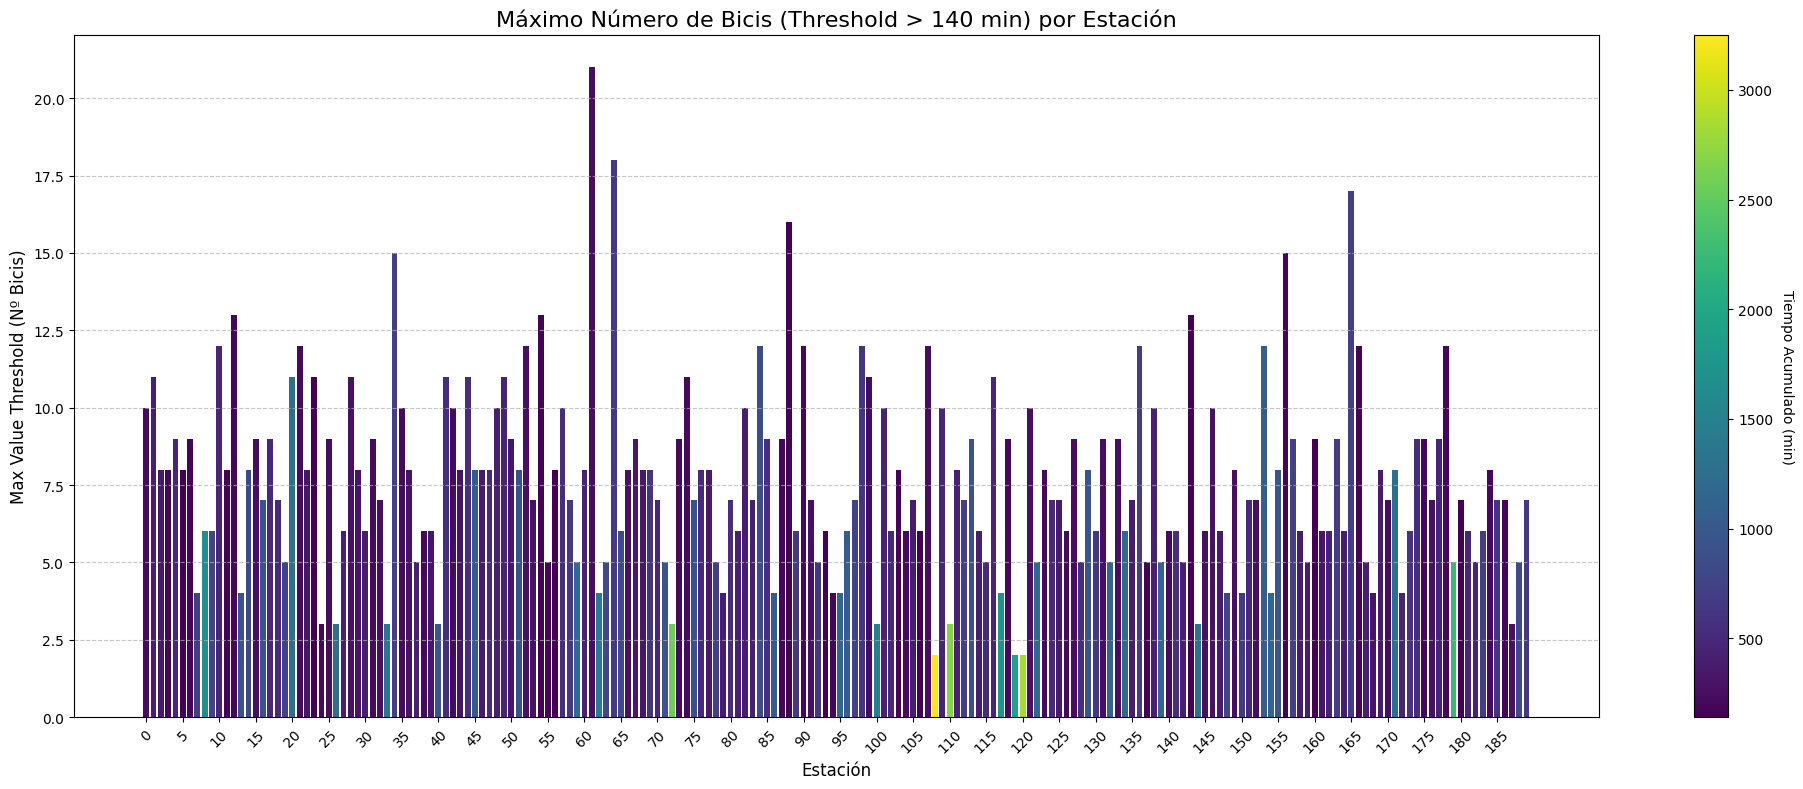

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asumiendo que tu dataframe se llama df_max_threshold
plt.figure(figsize=(20, 8))

# Normalizamos los tiempos para usarlos como mapa de color
norm = plt.Normalize(df_max_threshold['Accumulated_Time'].min(), df_max_threshold['Accumulated_Time'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

# Crear el gráfico de barras
# Eje X: Estaciones (índice), Eje Y: Valor Máximo
plt.bar(df_max_threshold.index, df_max_threshold['Max_Value_Threshold'],
        color=plt.cm.viridis(norm(df_max_threshold['Accumulated_Time'])),
        width=0.8)

plt.title('Máximo Número de Bicis (Threshold > 140 min) por Estación', fontsize=16)
plt.xlabel('Estación', fontsize=12)
plt.ylabel('Max Value Threshold (Nº Bicis)', fontsize=12)

# Añadir barra de color lateral
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Tiempo Acumulado (min)', rotation=270, labelpad=15)

# Ajustar etiquetas del eje X para que no se solapen (mostrar cada 5)
plt.xticks(df_max_threshold.index[::5], df_max_threshold.index[::5].astype(int), rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Ya tenemos el número de patinetes que debe tener cada estación. Según la información que hemos encontrado, el valor minimo debe ser 4 y el máximo debe ser 16.

In [76]:
NUM_MIN = 4
NUM_MAX = 16

df_tamaño = df_max_threshold.copy()

# Usamos clip: todo lo que baje de min se vuelve min, todo lo que suba de max se vuelve max
df_tamaño['Tamaño'] = df_tamaño['Max_Value_Threshold'].clip(lower=NUM_MIN, upper=NUM_MAX)

df_tamaño.drop(columns=['Max_Value_Threshold', 'Accumulated_Time'], inplace=True)
df_tamaño.sort_values('Tamaño')

,Tamaño
Station,
7.0,4
13.0,4
24.0,4
26.0,4
40.0,4
...,...
34.0,15
61.0,16
88.0,16


In [77]:
df_tamaño.to_csv('tamaño_cluster')

In [78]:
df_tamaño.value_counts()

,count
Tamaño,
6,29
8,29
4,25
7,24
9,22
5,20
10,11
12,11
11,10


In [80]:
df_tamaño['Tamaño'].sum()

np.int64(1457)